In [1]:
import os, sys, re, math, h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
# Get the parent directory
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)

from class_analysis import metrics_creator, plot_roman_rubin_plt, graph_maker, create_df_to_plot
from fit_lc import model_rubin_roman
from fit_lc import fit_rubin_roman
from pyLIMA.outputs import pyLIMA_plots
sys.path.append(os.path.dirname(os.getcwd()))
from read_save import read_data

from bokeh.plotting import figure, show, output_file
from bokeh.layouts import gridplot, row, column
from bokeh.io import export_png
from plot_saveLC import plot_n_save
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import corner
import seaborn as sns
import matplotlib.lines as mlines

from tqdm.auto import tqdm
from connect_CHE_private_account import download_data

Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [2]:
param_latex = lambda p: fr"$\frac{{\left|{{{{{p}}}}}^{{\text{{fit}}}} - {{{{{p}}}}}^{{{{true}}}}\right|}}{{{{{{{p}}}}}^{{\text{{true}}}}}}$"
dictionary_class = {'USBL': 'Planets bounded', 'PSPL':'Stellar Mass Black Holes', 'FSPL':'Free Floating Planets'}
category_colors = {'A': 'royalblue', 'B': 'darkorange', 'C': 'cyan', 'D': 'crimson'}
category_names = {'A': 'Roman + Rubin', 'B': ' Rubin', 'C': ' Roman' , 'D': 'None'}

relative_bias = {
    "rho":      r"$\frac{|\rho - \hat{\rho}|}{\rho}$",
    "pi_E":     r"$\frac{|\pi_E - \hat{\pi}_E|}{\pi_E}$",
    "t_E":      r"$\frac{|t_E - \hat{t}_E|}{t_E}$",
    "u_0":      r"$\frac{|u_0 - \hat{u}_0|}{u_0}$",
    "t_0":      r"$\frac{|t_0 - \hat{t}_0|}{t_0}$",
    "alpha":    r"$\frac{|\alpha - \hat{\alpha}|}{\alpha}$",
    "q":        r"$\frac{|q - \hat{q}|}{q}$"
}

In [3]:
# Directorios base
base_path = os.path.join(parent_directory, 'all_results')
models = ['FSPL_3', 'USBL_6','PSPL_3']
suffixes = ['true', 'fit_rr', 'fit_roman']

# Carga de datos
data = {}
for model in models:
    model_key = model.split('_')[0]  # 'FSPL' o 'USBL'
    model_path = os.path.join(base_path, model)
    data[model_key] = {
        suffix: pd.read_csv(os.path.join(model_path, f'{suffix}.csv'))
        for suffix in suffixes
    }
    data[model_key]['true']['piE'] = np.sqrt(data[model_key]['true']['piEE']**2+data[model_key]['true']['piEN']**2)

# Cálculo de métricas
metrics = {}
for model_key, fits in data.items():
    metrics[model_key] = {}
    for fit_key in ['fit_rr', 'fit_roman']:
        metrics[model_key][fit_key] = metrics_creator(
            fits['true'], fits[fit_key], model_key
        )

# Armado del MultiIndex DataFrame
index_tuples = []
values = []
for model_key, fits in metrics.items():
    for fit_key, metric_tuple in fits.items():
        index_tuples.append((model_key, fit_key))
        values.append(metric_tuple)
multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['model', 'fit'])
df_metrics = pd.DataFrame(values, index=multi_index, columns=['metric1', 'metric2', 'metric3'])

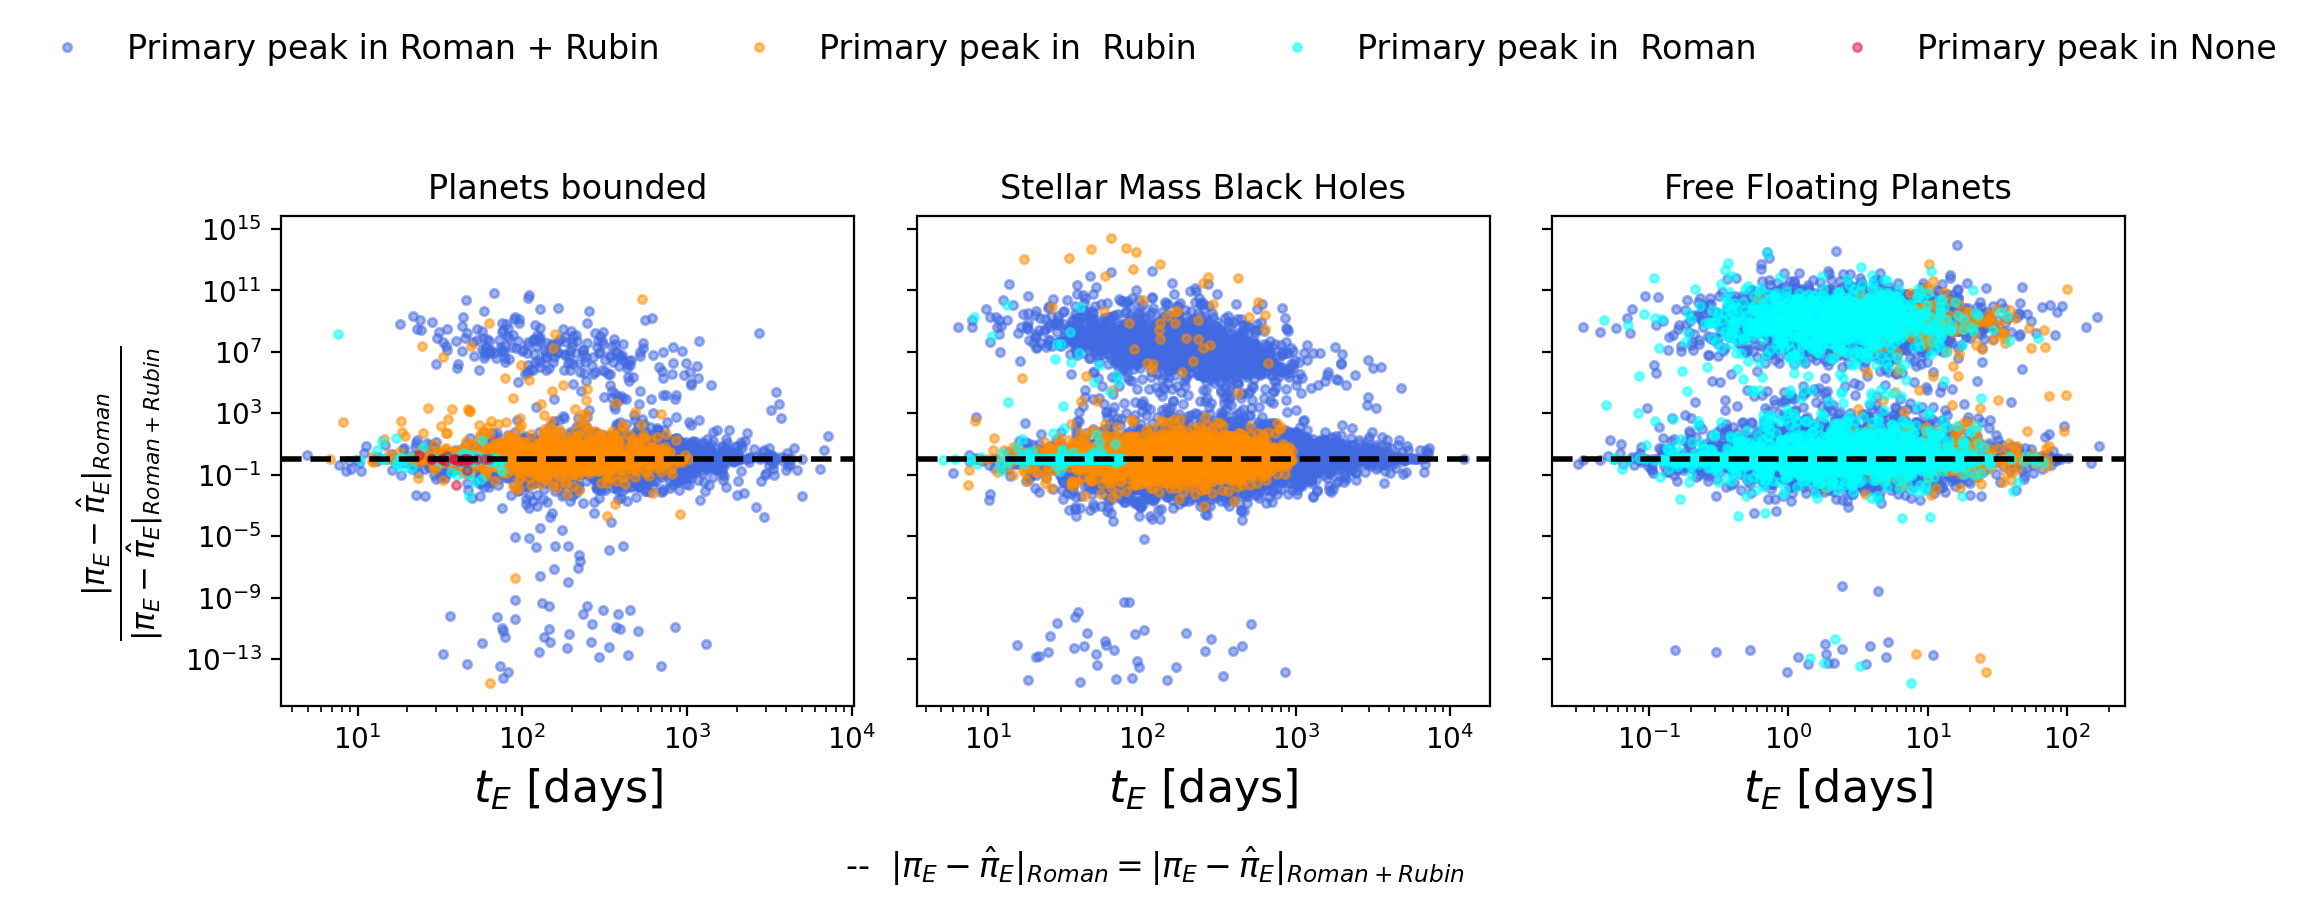

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200,sharey=True)
axs = axs.flatten()

example_handles = []
example_labels = []

for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
    df0 = df_metrics.loc[Class, 'fit_roman']['metric1']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
    df2 = data[Class]['true']
    
    for cat in ['A', 'B', 'C', 'D']:
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
        mask &= df1['tE'] != 0

        if not np.any(mask):
            continue

        p = axs[i].plot(
            df2['tE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            color=category_colors[cat],
            label=f'Primary peak in {category_names[cat]}',alpha=0.5
        )
        if i == 0:
            example_handles.append(p[0])
            example_labels.append(f'Primary peak in {category_names[cat]}')

    axs[i].axhline(1, color='k', linestyle='--', linewidth=2)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('$t_E$ [days]', fontsize=16)
    # axs[i].set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

# Leyenda de los colores arriba
fig.legend(example_handles, example_labels, loc='upper center', ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.2))

# Agregar texto manual para la línea horizontal
fig.text(
    0.5, -0.05,  # x, y en coordenadas de figura (0-1)
    r'--  $|\pi_E-\hat{\pi}_E|_{Roman} = |\pi_E-\hat{\pi}_E|_{Roman+Rubin}$',
    ha='center', fontsize=12, color='k'
)
fig.text(-0.04, 0.5, r'$\frac{|\pi_E-\hat{\pi}_E|_{Roman}}{|\pi_E-\hat{\pi}_E|_{Roman+Rubin}}$', va='center', rotation='vertical', fontsize=16)

os.makedirs('/home/anibal-pc/results_roman_rubin/metrics_plots', exist_ok=True)
plt.tight_layout()
plt.savefig('/home/anibal-pc/results_roman_rubin/metrics_plots/Bias_ratio_piE_vs_tE.png')
plt.show()

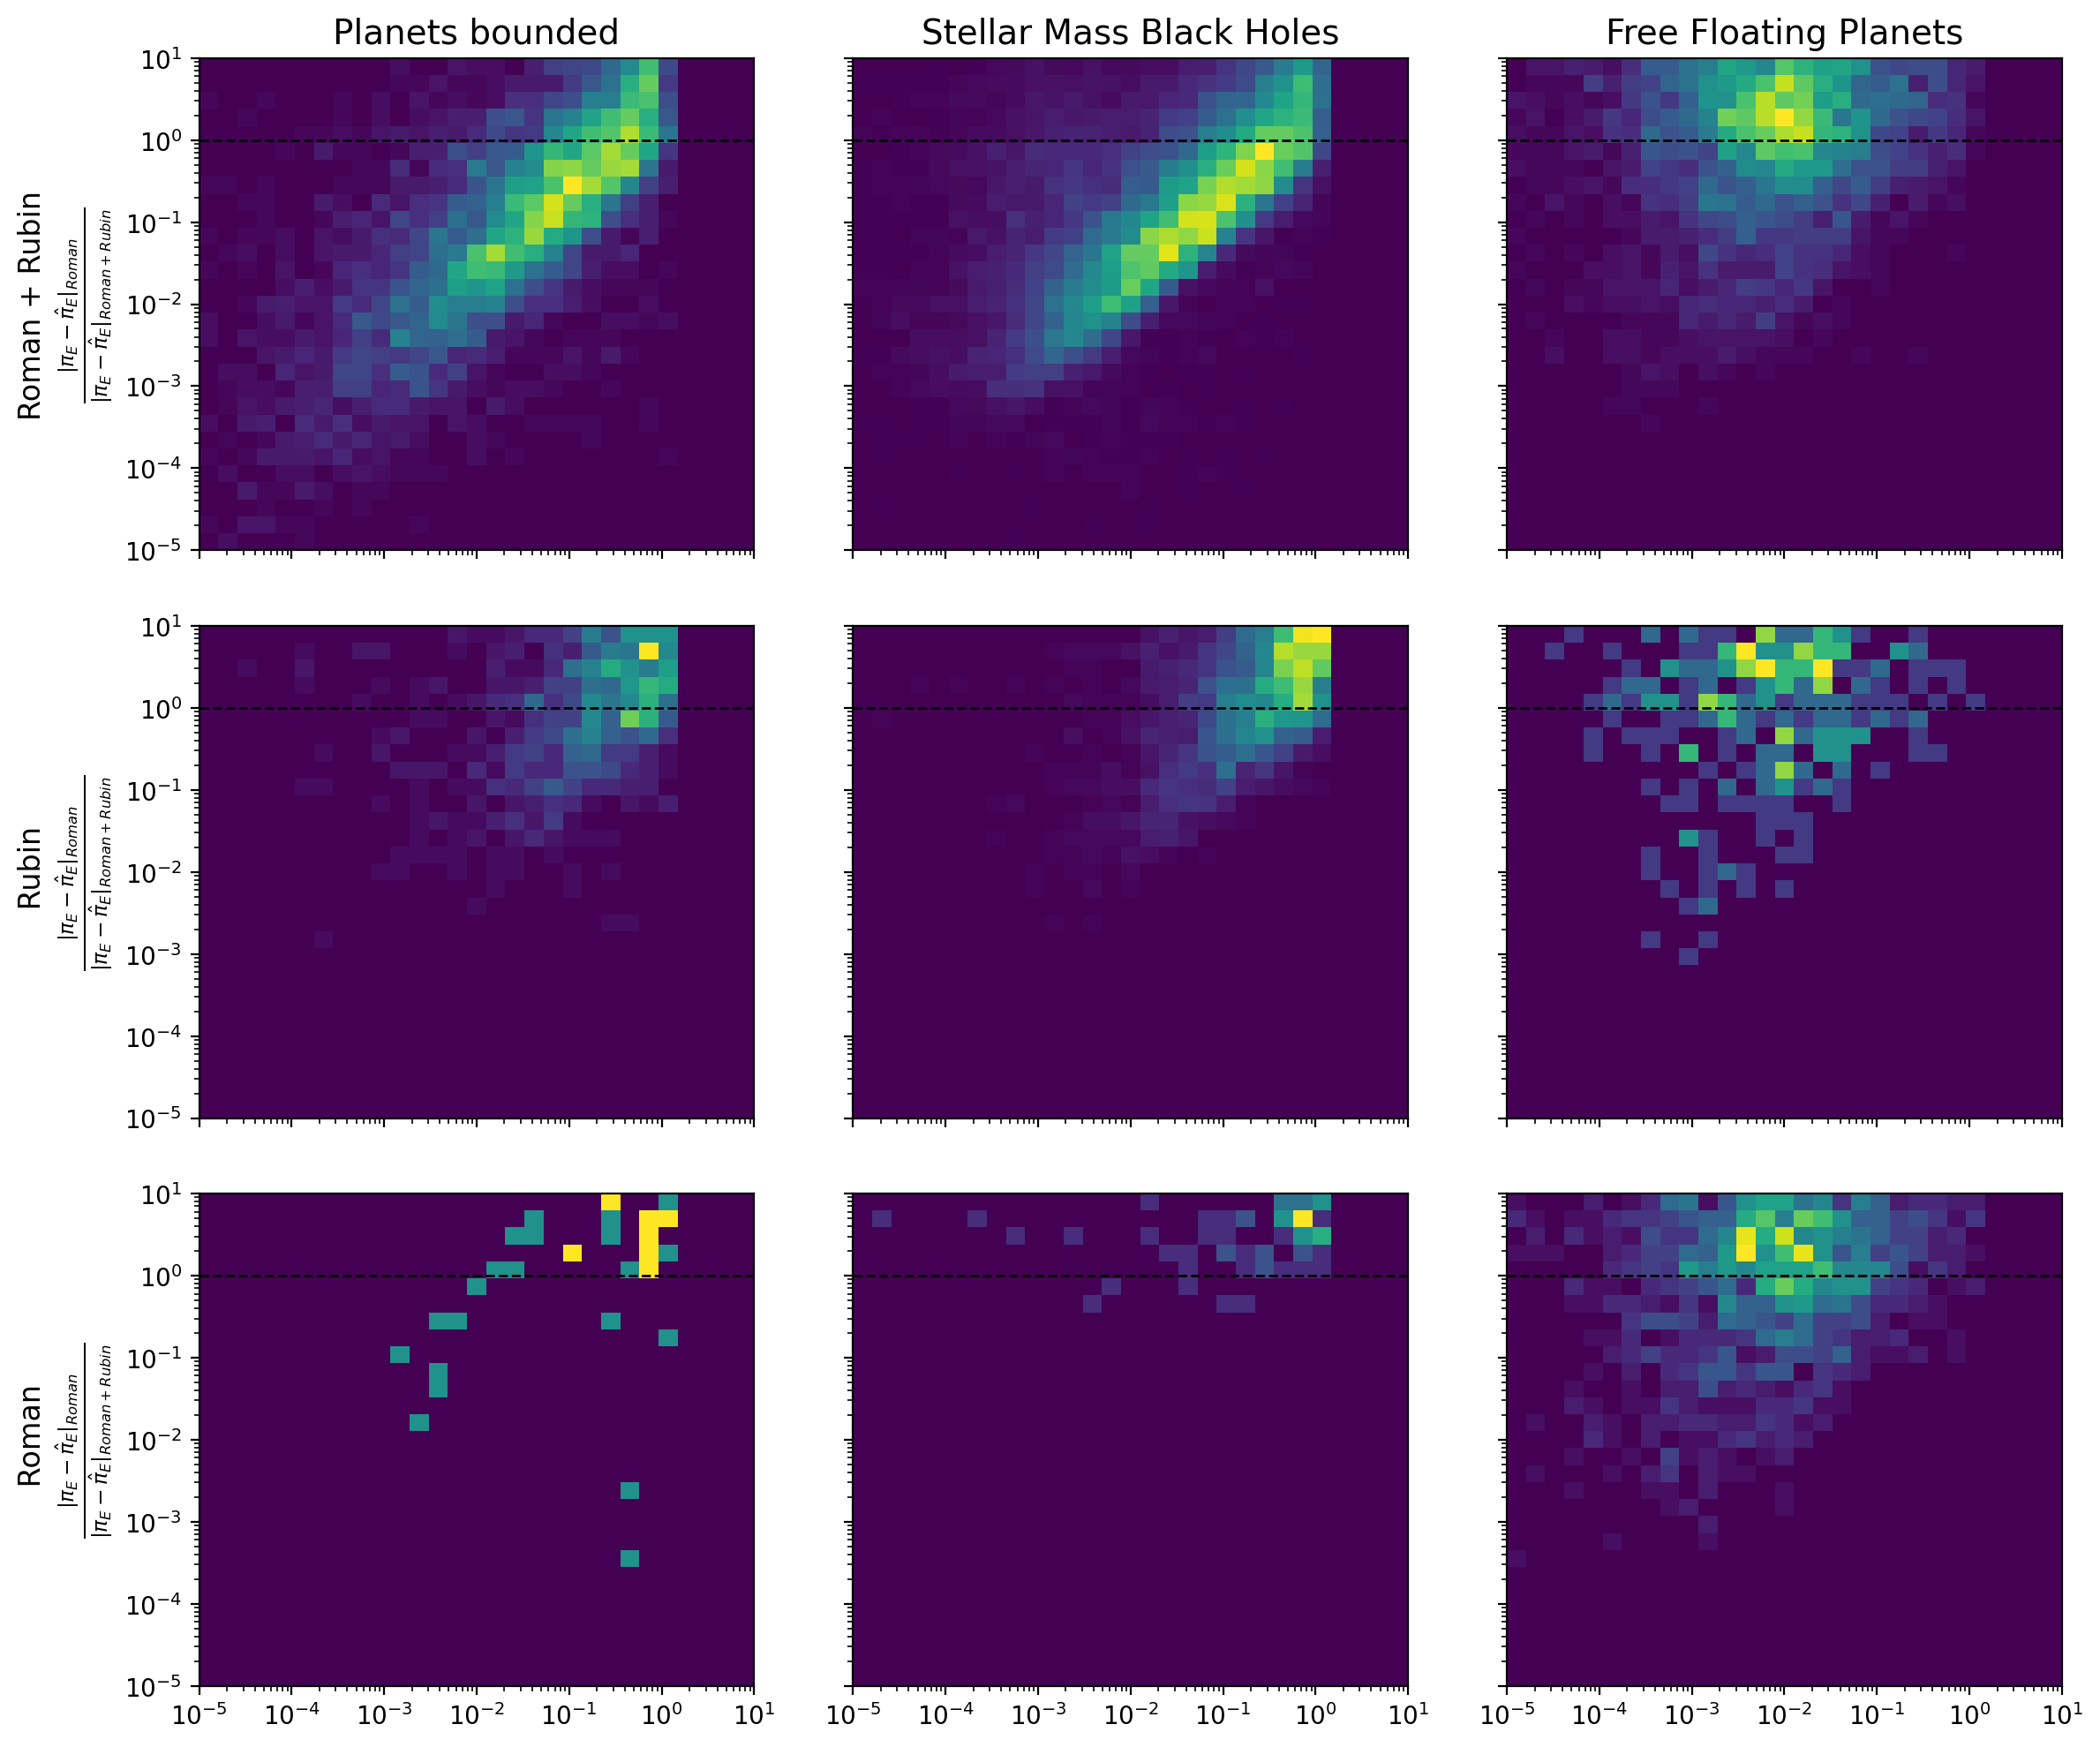

In [25]:
fig, axs = plt.subplots(3, 3, figsize=(12, 10), dpi=200, sharex=True, sharey=True)
axs = axs.reshape(3, 3)  # [row(category), column(class)]
for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
    df0 = df_metrics.loc[Class, 'fit_rr']['metric1']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric3']
    df2 = data[Class]['true']
    for j, cat in enumerate(['A', 'B', 'C']):
        ax = axs[j, i]
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
        mask &= df1['tE'] != 0
        if not np.any(mask):
            continue
        ax.hist2d(df0['piE'][mask], df1['piE'][mask], bins=(np.logspace(-5,1,30),np.logspace(-5,1,30)))
        ax.axhline(1, color='k', linestyle='--', linewidth=1)
        ax.set_xscale('log')
        ax.set_yscale('log')
        if j == 3:
            ax.set_xlabel('$t_E$ [days]', fontsize=12)
        if i == 0:
            ax.set_ylabel(fr'{category_names[cat]}' + '\n' + r'$\frac{|\pi_E - \hat{\pi}_E|_{Roman}}{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}$', fontsize=12)
        if j == 0:
            ax.set_title(dictionary_class[Class], fontsize=14)

# Ajustes finales
plt.tight_layout(h_pad=2, w_pad=2)

# Guardar
outdir = '/home/anibal-pc/results_roman_rubin/metrics_plots'
os.makedirs(outdir, exist_ok=True)
plt.savefig(os.path.join(outdir, 'Bias_ratio_piE_vs_tE_by_category.png'))
plt.show()

